# Add Macroeconomic Variables to HDB Dataset

This notebook adds interest rate and inflation variables to the merged HDB dataset.

**Variables to add:**
1. `sora_3m` - End-of-quarter 3-month compounded SORA (%)
2. `inflation_yoy` - Year-over-year inflation from RPI (%)
3. `real_interest_rate` - Real interest rate (sora_3m - inflation_yoy)
4. `sora_3m_lag1` - Previous quarter's SORA
5. `real_interest_rate_lag1` - Previous quarter's real rate

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load Existing Merged Dataset

In [99]:
# Load the existing merged dataset with RPI
merged_df = pd.read_csv('../merged_data/merged_hdb_resale_with_rpi.csv')

print(f"Loaded dataset shape: {merged_df.shape}")
print(f"\nColumns: {merged_df.columns.tolist()}")
print(f"\nDate range: {merged_df['quarter'].min()} to {merged_df['quarter'].max()}")
print(f"\nFirst few rows:")
merged_df.head()

Loaded dataset shape: (222077, 14)

Columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price', 'quarter', 'rpi', 'resale_price_real']

Date range: 2017-Q1 to 2025-Q4

First few rows:


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,quarter,rpi,resale_price_real
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017-Q1,133.9,232000.0
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017-Q1,133.9,250000.0
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017-Q1,133.9,262000.0
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017-Q1,133.9,265000.0
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017-Q1,133.9,265000.0


## Step 2: Process SORA Data (3-Month Compounded Interest Rates)

In [100]:
# Load SORA data (skip metadata rows)
print("Loading SORA data...")
sora_raw = pd.read_csv('../data/3MonthCompoundedSORA2017to2026.csv', skiprows=7)

print(f"Raw SORA shape: {sora_raw.shape}")
print(f"\nFirst few rows:")
print(sora_raw.head())
print(f"\nColumn names:")
print(sora_raw.columns.tolist())

Loading SORA data...
Raw SORA shape: (2302, 5)

First few rows:
  2017  Jan    03  04 Jan 2017  0.1478
0  NaN  NaN   4.0  05 Jan 2017  0.1488
1  NaN  NaN   5.0  06 Jan 2017  0.1494
2  NaN  NaN   6.0  09 Jan 2017  0.1498
3  NaN  NaN   9.0  10 Jan 2017  0.1490
4  NaN  NaN  10.0  11 Jan 2017  0.1485

Column names:
['2017', 'Jan', '03', '04 Jan 2017', '0.1478']


In [101]:
# Parse the SORA data - use the publication date column which is easier to parse
print("Parsing SORA dates...")

# The 4th column (index 3) contains formatted publication dates
sora_df = sora_raw.copy()
sora_df.columns = ['year', 'month', 'day', 'pub_date', 'sora_value']

# Remove the header row if it exists (first row contains column names)
sora_df = sora_df[sora_df['pub_date'] != 'SORA Publication Date'].copy()

# Parse the publication date
sora_df['date'] = pd.to_datetime(sora_df['pub_date'], format='%d %b %Y')

# Convert SORA value to numeric (it's already in percentage format, e.g., 0.1478 = 0.1478%)
sora_df['sora_value'] = pd.to_numeric(sora_df['sora_value'], errors='coerce')

# Sort by date
sora_df = sora_df.sort_values('date')

print(f"\nParsed SORA data:")
print(sora_df[['date', 'sora_value']].head(10))
print(f"\nDate range: {sora_df['date'].min()} to {sora_df['date'].max()}")
print(f"SORA value range: {sora_df['sora_value'].min():.4f}% to {sora_df['sora_value'].max():.4f}%")

Parsing SORA dates...

Parsed SORA data:
        date  sora_value
0 2017-01-05      0.1488
1 2017-01-06      0.1494
2 2017-01-09      0.1498
3 2017-01-10      0.1490
4 2017-01-11      0.1485
5 2017-01-12      0.1476
6 2017-01-13      0.1470
7 2017-01-16      0.1490
8 2017-01-17      0.1493
9 2017-01-18      0.1507

Date range: 2017-01-05 00:00:00 to 2026-02-10 00:00:00
SORA value range: 0.0696% to 3.7611%


In [102]:
# Extract end-of-quarter SORA values
print("Extracting end-of-quarter SORA values...")

# Drop rows where date couldn't be parsed
sora_df = sora_df.dropna(subset=['date']).copy()

# Add quarter information
sora_df['year'] = sora_df['date'].dt.year
sora_df['quarter_num'] = sora_df['date'].dt.quarter
sora_df['quarter'] = sora_df['year'].astype(int).astype(str) + '-Q' + sora_df['quarter_num'].astype(int).astype(str)

# For each quarter, get the LAST available trading day's value
sora_quarterly = sora_df.groupby('quarter').agg({
    'date': 'max',  # Last trading day in quarter
    'sora_value': 'last'  # Value on that last day
}).reset_index()

# Rename for clarity
sora_quarterly = sora_quarterly.rename(columns={'sora_value': 'sora_3m'})

print(f"\nQuarterly SORA summary:")
print(sora_quarterly.head(10))
print(f"\nTotal quarters: {len(sora_quarterly)}")
print(f"\nSummary statistics:")
print(sora_quarterly['sora_3m'].describe())

Extracting end-of-quarter SORA values...

Quarterly SORA summary:
   quarter       date  sora_3m
0  2017-Q1 2017-03-31   0.2567
1  2017-Q2 2017-06-30   0.4846
2  2017-Q3 2017-09-29   0.7160
3  2017-Q4 2017-12-29   0.8358
4  2018-Q1 2018-03-29   0.6820
5  2018-Q2 2018-06-29   0.8872
6  2018-Q3 2018-09-28   1.2199
7  2018-Q4 2018-12-31   1.4504
8  2019-Q1 2019-03-29   1.5284
9  2019-Q2 2019-06-28   1.7350

Total quarters: 37

Summary statistics:
count    37.000000
mean      1.554824
std       1.276201
min       0.099700
25%       0.484600
50%       1.219900
75%       2.561800
max       3.709000
Name: sora_3m, dtype: float64


## Step 3: Calculate Inflation from RPI (Year-over-Year)

In [103]:
# Calculate year-over-year inflation from RPI
print("Calculating year-over-year inflation...")

# Get unique quarters with RPI
rpi_df = merged_df[['quarter', 'rpi']].drop_duplicates().sort_values('quarter')

print(f"\nRPI data:")
print(rpi_df.head(10))

# Calculate YoY inflation (compare to same quarter last year)
# Need to shift by 4 quarters (1 year)
rpi_df['rpi_lag4'] = rpi_df['rpi'].shift(4)
rpi_df['inflation_yoy'] = ((rpi_df['rpi'] - rpi_df['rpi_lag4']) / rpi_df['rpi_lag4']) * 100

print(f"\nInflation calculation (first 12 quarters):")
print(rpi_df[['quarter', 'rpi', 'rpi_lag4', 'inflation_yoy']].head(12))

# Note: First 4 quarters will have NaN inflation (no prior year to compare)
print(f"\nQuarters with NaN inflation: {rpi_df['inflation_yoy'].isna().sum()}")
print(f"Inflation range (excluding NaN): {rpi_df['inflation_yoy'].min():.2f}% to {rpi_df['inflation_yoy'].max():.2f}%")

Calculating year-over-year inflation...



RPI data:
       quarter    rpi
0      2017-Q1  133.9
4173   2017-Q2  133.7
9739   2017-Q3  132.8
15159  2017-Q4  132.6
20509  2018-Q1  131.6
24645  2018-Q2  131.7
30198  2018-Q3  131.6
36789  2018-Q4  131.4
42070  2019-Q1  131.0
46577  2019-Q2  130.8

Inflation calculation (first 12 quarters):
       quarter    rpi  rpi_lag4  inflation_yoy
0      2017-Q1  133.9       NaN            NaN
4173   2017-Q2  133.7       NaN            NaN
9739   2017-Q3  132.8       NaN            NaN
15159  2017-Q4  132.6       NaN            NaN
20509  2018-Q1  131.6     133.9      -1.717700
24645  2018-Q2  131.7     133.7      -1.495886
30198  2018-Q3  131.6     132.8      -0.903614
36789  2018-Q4  131.4     132.6      -0.904977
42070  2019-Q1  131.0     131.6      -0.455927
46577  2019-Q2  130.8     131.7      -0.683371
52446  2019-Q3  130.9     131.6      -0.531915
58292  2019-Q4  131.5     131.4       0.076104

Quarters with NaN inflation: 4
Inflation range (excluding NaN): -1.72% to 12.74%


## Step 4: Merge SORA and Inflation Data

In [104]:
# Merge SORA and inflation data
print("Merging SORA and inflation data...")

macro_df = sora_quarterly[['quarter', 'sora_3m']].merge(
    rpi_df[['quarter', 'inflation_yoy']], 
    on='quarter', 
    how='outer'
).sort_values('quarter')

print(f"\nMerged macro data:")
print(macro_df.head(12))

# Calculate real interest rate
macro_df['real_interest_rate'] = macro_df['sora_3m'] - macro_df['inflation_yoy']

print(f"\nWith real interest rate:")
print(macro_df[['quarter', 'sora_3m', 'inflation_yoy', 'real_interest_rate']].head(12))

Merging SORA and inflation data...

Merged macro data:
    quarter  sora_3m  inflation_yoy
0   2017-Q1   0.2567            NaN
1   2017-Q2   0.4846            NaN
2   2017-Q3   0.7160            NaN
3   2017-Q4   0.8358            NaN
4   2018-Q1   0.6820      -1.717700
5   2018-Q2   0.8872      -1.495886
6   2018-Q3   1.2199      -0.903614
7   2018-Q4   1.4504      -0.904977
8   2019-Q1   1.5284      -0.455927
9   2019-Q2   1.7350      -0.683371
10  2019-Q3   1.5273      -0.531915
11  2019-Q4   1.2682       0.076104

With real interest rate:
    quarter  sora_3m  inflation_yoy  real_interest_rate
0   2017-Q1   0.2567            NaN                 NaN
1   2017-Q2   0.4846            NaN                 NaN
2   2017-Q3   0.7160            NaN                 NaN
3   2017-Q4   0.8358            NaN                 NaN
4   2018-Q1   0.6820      -1.717700            2.399700
5   2018-Q2   0.8872      -1.495886            2.383086
6   2018-Q3   1.2199      -0.903614            2.123514
7  

## Step 5: Create Lagged Variables

In [105]:
# Create lag-1 variables (previous quarter)
print("Creating lagged variables...")

macro_df = macro_df.sort_values('quarter')
macro_df['sora_3m_lag1'] = macro_df['sora_3m'].shift(1)
macro_df['real_interest_rate_lag1'] = macro_df['real_interest_rate'].shift(1)

print(f"\nMacro variables with lags:")
print(macro_df[[
    'quarter', 'sora_3m', 'sora_3m_lag1', 
    'inflation_yoy', 'real_interest_rate', 'real_interest_rate_lag1'
]].head(15))

print(f"\nMissing values summary:")
print(macro_df.isna().sum())

Creating lagged variables...

Macro variables with lags:
    quarter  sora_3m  sora_3m_lag1  inflation_yoy  real_interest_rate  \
0   2017-Q1   0.2567           NaN            NaN                 NaN   
1   2017-Q2   0.4846        0.2567            NaN                 NaN   
2   2017-Q3   0.7160        0.4846            NaN                 NaN   
3   2017-Q4   0.8358        0.7160            NaN                 NaN   
4   2018-Q1   0.6820        0.8358      -1.717700            2.399700   
5   2018-Q2   0.8872        0.6820      -1.495886            2.383086   
6   2018-Q3   1.2199        0.8872      -0.903614            2.123514   
7   2018-Q4   1.4504        1.2199      -0.904977            2.355377   
8   2019-Q1   1.5284        1.4504      -0.455927            1.984327   
9   2019-Q2   1.7350        1.5284      -0.683371            2.418371   
10  2019-Q3   1.5273        1.7350      -0.531915            2.059215   
11  2019-Q4   1.2682        1.5273       0.076104            1.1920

## Step 6: Merge Macro Variables with Main Dataset

In [106]:
# Merge macro variables into main dataset
print("Merging macro variables into main dataset...")

# Select only the new macro variables to merge
macro_to_merge = macro_df[[
    'quarter', 'sora_3m', 'inflation_yoy', 'real_interest_rate',
    'sora_3m_lag1', 'real_interest_rate_lag1'
]]

# Merge with main dataset
enhanced_df = merged_df.merge(macro_to_merge, on='quarter', how='left')

print(f"\nEnhanced dataset shape: {enhanced_df.shape}")
print(f"\nNew columns added: {set(enhanced_df.columns) - set(merged_df.columns)}")
print(f"\nFirst few rows:")
enhanced_df[[
    'quarter', 'resale_price', 'rpi', 'sora_3m', 
    'inflation_yoy', 'real_interest_rate'
]].head(10)

Merging macro variables into main dataset...

Enhanced dataset shape: (222077, 19)

New columns added: {'inflation_yoy', 'sora_3m_lag1', 'real_interest_rate', 'sora_3m', 'real_interest_rate_lag1'}

First few rows:


,quarter,resale_price,rpi,sora_3m,inflation_yoy,real_interest_rate
0,2017-Q1,232000.0,133.9,0.2567,NaN,NaN
1,2017-Q1,250000.0,133.9,0.2567,NaN,NaN
2,2017-Q1,262000.0,133.9,0.2567,NaN,NaN
3,2017-Q1,265000.0,133.9,0.2567,NaN,NaN
4,2017-Q1,265000.0,133.9,0.2567,NaN,NaN
5,2017-Q1,275000.0,133.9,0.2567,NaN,NaN
6,2017-Q1,280000.0,133.9,0.2567,NaN,NaN
7,2017-Q1,285000.0,133.9,0.2567,NaN,NaN
8,2017-Q1,285000.0,133.9,0.2567,NaN,NaN
9,2017-Q1,285000.0,133.9,0.2567,NaN,NaN


## Step 7: Quality Checks and Validation

In [107]:
# Quality checks
print("=" * 70)
print("QUALITY CHECKS")
print("=" * 70)

# 1. Check for missing values
print("\n1. Missing Values Count:")
print(enhanced_df[[
    'sora_3m', 'inflation_yoy', 'real_interest_rate',
    'sora_3m_lag1', 'real_interest_rate_lag1'
]].isna().sum())

# 2. Summary statistics
print("\n2. Summary Statistics for New Variables:")
print(enhanced_df[[
    'sora_3m', 'inflation_yoy', 'real_interest_rate',
    'sora_3m_lag1', 'real_interest_rate_lag1'
]].describe())

# 3. Check value ranges
print("\n3. Value Ranges Check:")
print(f"   SORA range: {enhanced_df['sora_3m'].min():.4f}% to {enhanced_df['sora_3m'].max():.4f}%")
print(f"   Expected: 0.1% to 4.0% ✓" if 0.1 <= enhanced_df['sora_3m'].min() and enhanced_df['sora_3m'].max() <= 4.0 else "   WARNING: Outside expected range!")

print(f"   Inflation range: {enhanced_df['inflation_yoy'].min():.2f}% to {enhanced_df['inflation_yoy'].max():.2f}%")
print(f"   Expected: -2% to 5% ✓" if -2 <= enhanced_df['inflation_yoy'].min() and enhanced_df['inflation_yoy'].max() <= 5 else "   WARNING: Outside expected range!")

print(f"   Real rate range: {enhanced_df['real_interest_rate'].min():.2f}% to {enhanced_df['real_interest_rate'].max():.2f}%")

# 4. Check for duplicates or anomalies
print("\n4. Data Integrity:")
print(f"   Total rows: {len(enhanced_df):,}")
print(f"   Quarters covered: {enhanced_df['quarter'].nunique()}")
print(f"   Date range: {enhanced_df['quarter'].min()} to {enhanced_df['quarter'].max()}")

QUALITY CHECKS

1. Missing Values Count:
sora_3m                        0
inflation_yoy              20509
real_interest_rate         20509
sora_3m_lag1                4173
real_interest_rate_lag1    24645
dtype: int64

2. Summary Statistics for New Variables:
             sora_3m  inflation_yoy  real_interest_rate   sora_3m_lag1  \
count  222077.000000  201568.000000       201568.000000  217904.000000   
mean        1.616106       6.002722           -4.282313       1.600617   
std         1.306586       4.699348            4.786397       1.335526   
min         0.099700      -1.717700          -12.557688       0.099700   
25%         0.272600       0.840979           -7.308024       0.256700   
50%         1.268200       6.640182           -4.141656       1.268200   
75%         3.071700       9.700665           -0.697979       3.071700   
max         3.709000      12.744388            2.418371       3.709000   

       real_interest_rate_lag1  
count            197432.000000  
mean  


5. Correlation Matrix of Macro Variables:


                         rpi   sora_3m  inflation_yoy  real_interest_rate
rpi                 1.000000  0.656947       0.508972           -0.325089
sora_3m             0.656947  1.000000       0.074837            0.203572
inflation_yoy       0.508972  0.074837       1.000000           -0.961080
real_interest_rate -0.325089  0.203572      -0.961080            1.000000


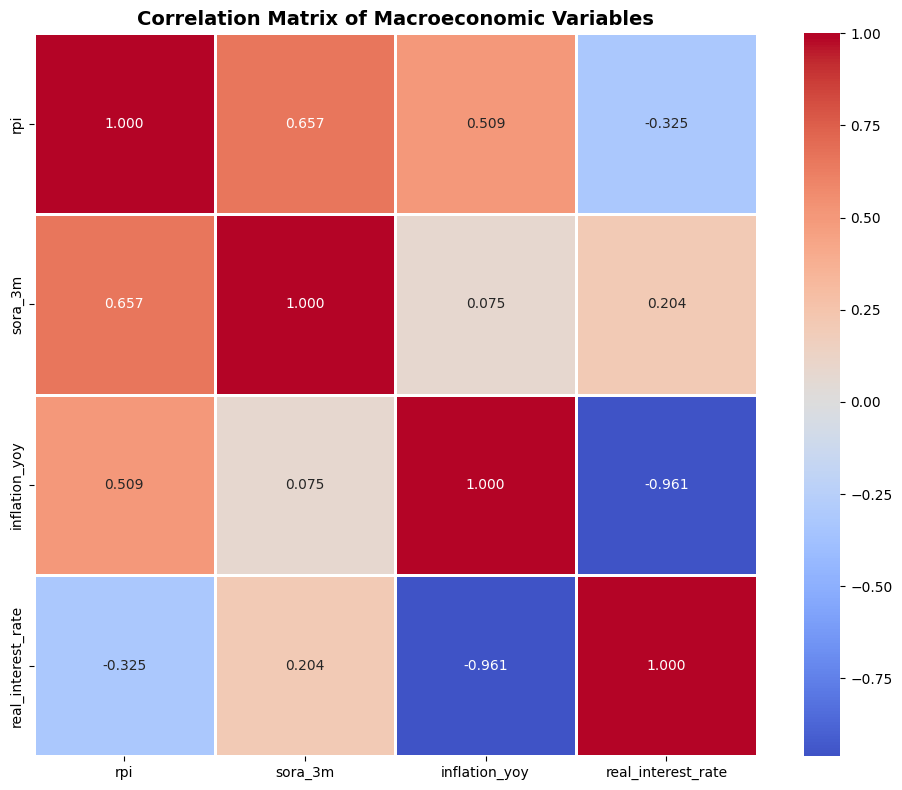


Key observations:
   - RPI vs SORA: 0.657
   - SORA vs Real Rate: 0.204
   - Inflation vs Real Rate: -0.961


In [108]:
# Check correlations between macro variables
print("\n5. Correlation Matrix of Macro Variables:")

macro_vars = ['rpi', 'sora_3m', 'inflation_yoy', 'real_interest_rate']
corr_matrix = enhanced_df[macro_vars].corr()

print(corr_matrix)

# Visualize correlation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=1)
plt.title('Correlation Matrix of Macroeconomic Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"   - RPI vs SORA: {corr_matrix.loc['rpi', 'sora_3m']:.3f}")
print(f"   - SORA vs Real Rate: {corr_matrix.loc['sora_3m', 'real_interest_rate']:.3f}")
print(f"   - Inflation vs Real Rate: {corr_matrix.loc['inflation_yoy', 'real_interest_rate']:.3f}")


6. Time Series Visualization:


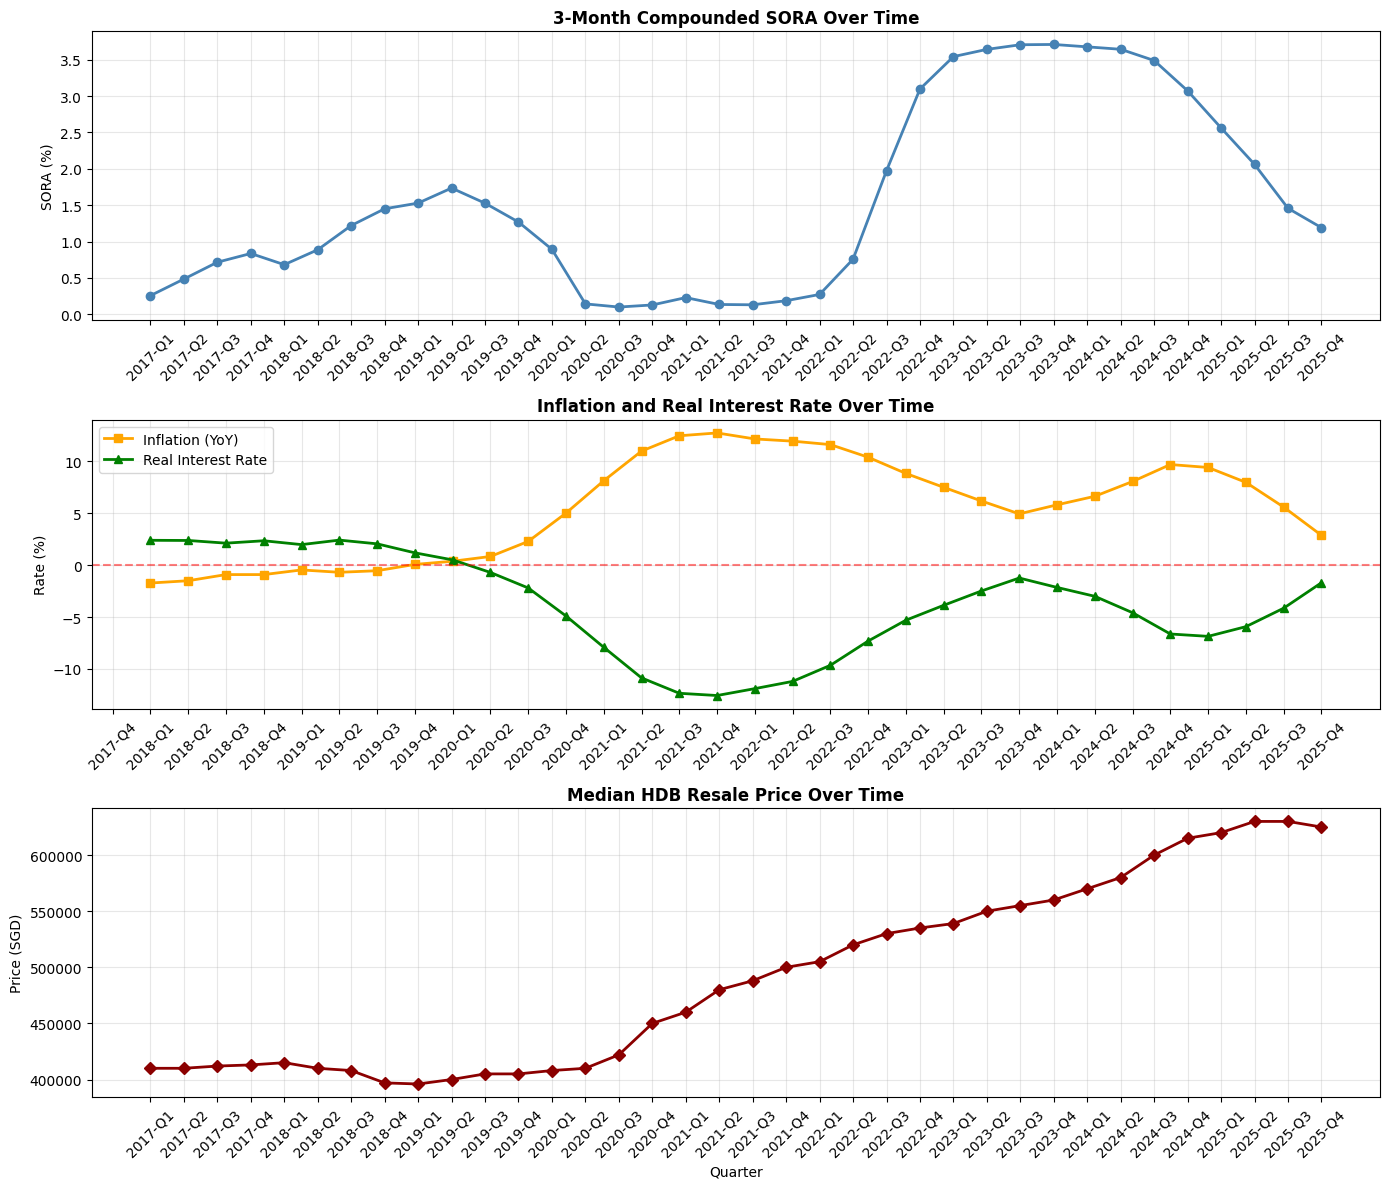

In [109]:
# Visualize time series trends
print("\n6. Time Series Visualization:")

# Create quarterly aggregated data for plotting
quarterly_plot = enhanced_df.groupby('quarter').agg({
    'sora_3m': 'first',
    'inflation_yoy': 'first',
    'real_interest_rate': 'first',
    'resale_price': 'median'
}).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: SORA over time
axes[0].plot(quarterly_plot['quarter'], quarterly_plot['sora_3m'], 
             marker='o', linewidth=2, color='steelblue')
axes[0].set_title('3-Month Compounded SORA Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('SORA (%)', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Inflation and Real Interest Rate
axes[1].plot(quarterly_plot['quarter'], quarterly_plot['inflation_yoy'], 
             marker='s', linewidth=2, color='orange', label='Inflation (YoY)')
axes[1].plot(quarterly_plot['quarter'], quarterly_plot['real_interest_rate'], 
             marker='^', linewidth=2, color='green', label='Real Interest Rate')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Inflation and Real Interest Rate Over Time', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rate (%)', fontsize=10)
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Median HDB Resale Price
axes[2].plot(quarterly_plot['quarter'], quarterly_plot['resale_price'], 
             marker='D', linewidth=2, color='darkred')
axes[2].set_title('Median HDB Resale Price Over Time', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Price (SGD)', fontsize=10)
axes[2].set_xlabel('Quarter', fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Step 8: Save Enhanced Dataset and Documentation

In [ ]:
# Filter to start from 2020-Q1
print(f"Rows before filtering: {len(enhanced_df):,}")
enhanced_df = enhanced_df[enhanced_df['quarter'] >= '2020-Q1'].copy()
print(f"Rows after filtering (from 2020-Q1 onwards): {len(enhanced_df):,}")

# Save the enhanced dataset
output_file = '../merged_data/merged_hdb_resale_with_macro.csv'
print(f"\nSaving enhanced dataset to {output_file}...")
enhanced_df.to_csv(output_file, index=False)
print("Enhanced dataset saved!")

# Save quarterly macro summary
quarterly_summary = macro_df[[
    'quarter', 'sora_3m', 'inflation_yoy', 'real_interest_rate',
    'sora_3m_lag1', 'real_interest_rate_lag1'
]].copy()

# Add transaction count
trans_count = enhanced_df.groupby('quarter').size().reset_index(name='num_transactions')
quarterly_summary = quarterly_summary.merge(trans_count, on='quarter', how='left')

summary_file = '../merged_data/quarterly_macro_summary.csv'
print(f"\nSaving quarterly summary to {summary_file}...")
quarterly_summary.to_csv(summary_file, index=False)
print("Quarterly summary saved!")

print(f"\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Enhanced dataset: {len(enhanced_df):,} rows x {len(enhanced_df.columns)} columns")
print(f"Date range: {enhanced_df['quarter'].min()} to {enhanced_df['quarter'].max()}")
print(f"\nMissing values in macro variables:")
print(enhanced_df[['sora_3m', 'inflation_yoy', 'real_interest_rate', 'sora_3m_lag1', 'real_interest_rate_lag1']].isna().sum())

In [111]:
# Create data dictionary
dictionary_content = """# Macroeconomic Variables Data Dictionary

## New Variables Added to HDB Resale Dataset

### 1. sora_3m
**Description**: 3-Month Compounded Singapore Overnight Rate Average (SORA)  
**Units**: Percentage (%)  
**Calculation**: End-of-quarter value from daily 3-month compounded SORA  
**Source**: Monetary Authority of Singapore (MAS)  
**Expected Range**: 0.1% to 4.0%  
**Notes**: 
- This is the benchmark interest rate for housing loans in Singapore
- Each daily value is already a 3-month backward-looking compounded average
- We use the LAST trading day of each quarter as the representative value

### 2. inflation_yoy
**Description**: Year-over-year inflation rate based on HDB Resale Price Index (RPI)  
**Units**: Percentage (%)  
**Calculation**: `((RPI_current_quarter - RPI_same_quarter_last_year) / RPI_same_quarter_last_year) * 100`  
**Source**: Derived from HDB Resale Price Index  
**Expected Range**: -2% to 5%  
**Notes**:
- First 4 quarters (2017 Q1-Q4) have NaN values (no prior year for comparison)
- Uses housing-specific price index (RPI) rather than general CPI
- Negative values indicate deflation in housing prices

### 3. real_interest_rate
**Description**: Real interest rate adjusted for inflation  
**Units**: Percentage (%)  
**Calculation**: `sora_3m - inflation_yoy`  
**Expected Range**: -3% to 5%  
**Notes**:
- Represents the true cost of borrowing after accounting for inflation
- Negative values indicate that inflation exceeds nominal interest rates
- More economically meaningful than nominal rates for housing affordability

### 4. sora_3m_lag1
**Description**: Previous quarter's 3-month compounded SORA  
**Units**: Percentage (%)  
**Calculation**: Lag-1 shift of sora_3m  
**Notes**:
- First quarter (2017 Q1) has NaN value
- Captures lagged effect of interest rates on housing prices
- Housing prices typically respond to interest rate changes with 1-3 quarter delay

### 5. real_interest_rate_lag1
**Description**: Previous quarter's real interest rate  
**Units**: Percentage (%)  
**Calculation**: Lag-1 shift of real_interest_rate  
**Notes**:
- First 5 quarters have NaN values (needs both inflation and lag)
- Captures lagged real borrowing cost effect

## Usage Guidelines for Modeling

### For Linear Regression / Hedonic Models:
**Recommended**: Use `real_interest_rate` OR `real_interest_rate_lag1` (NOT both, and NOT with sora_3m or inflation_yoy)

**Rationale**: Avoid multicollinearity
- real_interest_rate = sora_3m - inflation_yoy (perfect mathematical relationship)
- Including multiple related variables causes unstable coefficients

**Example feature set**:
```python
features_linear = ['floor_area_sqm', 'storey_range', 'town', 'real_interest_rate']
```

### For Random Forest / Tree-Based Models:
**Recommended**: Use ALL macro variables

**Rationale**: Let the model select the most predictive features
- Tree-based models handle multicollinearity well
- Can discover which lag period is most predictive

**Example feature set**:
```python
features_rf = ['floor_area_sqm', 'storey_range', 'town', 
               'sora_3m', 'sora_3m_lag1', 'inflation_yoy', 
               'real_interest_rate', 'real_interest_rate_lag1']
```

### For Neural Networks:
**Recommended**: Use ALL macro variables (network can learn relationships)

## Expected Missing Value Patterns

| Variable | Expected NaN Count | Affected Quarters | Reason |
|----------|-------------------|-------------------|--------|
| sora_3m | 0 | None | SORA data available for all quarters |
| inflation_yoy | 4 quarters worth | 2017 Q1-Q4 | Need prior year for YoY calculation |
| real_interest_rate | 4 quarters worth | 2017 Q1-Q4 | Depends on inflation_yoy |
| sora_3m_lag1 | 1 quarter worth | 2017 Q1 | First quarter has no prior |
| real_interest_rate_lag1 | 5 quarters worth | 2017 Q1-2018 Q1 | Combines inflation + lag |

## Data Quality Checks Performed

1. Value ranges within expected bounds
2. No gaps in quarterly coverage (2017 Q1 onwards)
3. Consistent merge with transaction data
4. Correlation matrix validated
5. Temporal consistency (no future data leakage)

## References

- SORA: https://www.mas.gov.sg/monetary-policy/sora
- HDB Resale Price Index: https://data.gov.sg/

## Version History

- v1.0 (2025-02): Initial creation with 5 macro variables
"""

dict_file = '../merged_data/MACRO_VARIABLES_DICTIONARY.md'
print(f"Creating data dictionary at {dict_file}...")
with open(dict_file, 'w') as f:
    f.write(dictionary_content)
print("Data dictionary created!")

Creating data dictionary at ../merged_data/MACRO_VARIABLES_DICTIONARY.md...
Data dictionary created!


## Next Steps

The enhanced dataset is now ready for modeling! Here's what you can do:

### 1. Load the enhanced dataset:
```python
df = pd.read_csv('../merged_data/merged_hdb_resale_with_macro.csv')
```

### 2. Create feature sets for different models:

**For Multiple Regression (Baseline):**
```python
features_linear = [
    'floor_area_sqm', 'storey_range', 'lease_commence_date',
    'town', 'flat_type', 'real_interest_rate_lag1'  # Use lag for better prediction
]
```

**For Random Forest:**
```python
features_rf = [
    'floor_area_sqm', 'storey_range', 'lease_commence_date',
    'town', 'flat_type',
    'sora_3m', 'sora_3m_lag1',  # Let model pick best lag
    'inflation_yoy', 'real_interest_rate', 'real_interest_rate_lag1'
]
```

### 3. Implement time-based train/test split:
```python
# Example: Train on 2020-2023, Test on 2024-2025
train = df[df['quarter'] < '2024-Q1']
test  = df[df['quarter'] >= '2024-Q1']
```